In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,ConfusionMatrixDisplay

In [2]:
## 1. Load Dataset

df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)


(7043, 21)


In [3]:
## 2. Data Cleaning

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].median())
df.drop('customerID', axis=1, inplace=True)

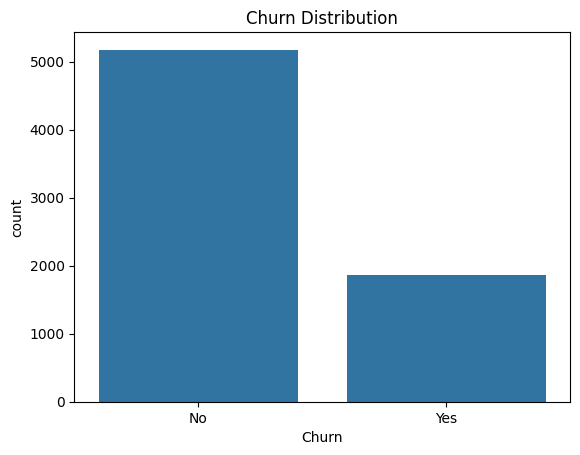

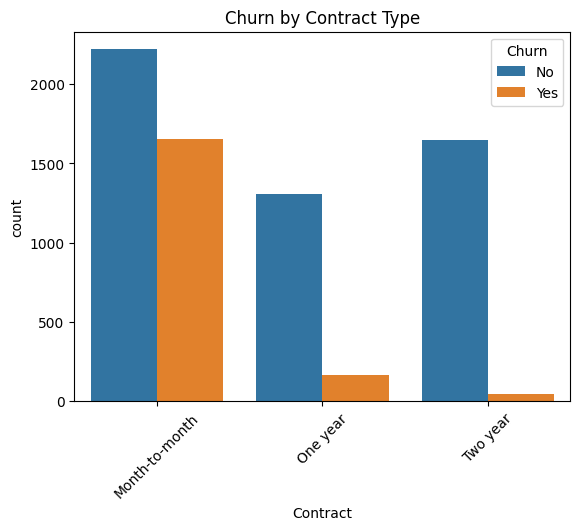

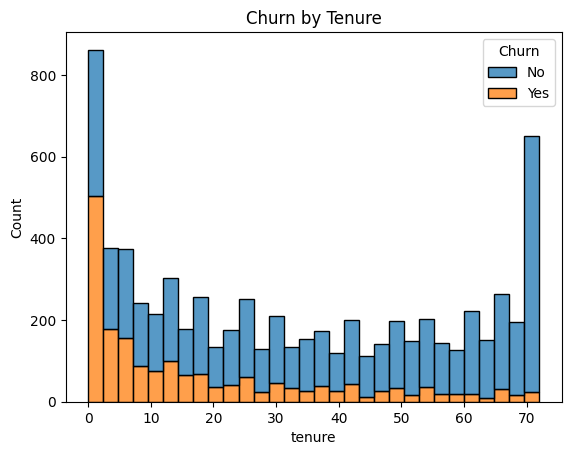

In [4]:
## 3. Exploratory Data Analysis

sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.xticks(rotation=45)
plt.show()

sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.title('Churn by Tenure')
plt.show()

In [5]:
## 4. Encoding Categorical Variables

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, drop_first=True)
x = df.drop('Churn', axis=1)
y = df['Churn']

In [6]:
## 5. Train-Test Split

x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
## 6. Handling Class Imbalance

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_train_sm,y_train_sm = smote.fit_resample(x_train, y_train)
print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", y_train_sm.value_counts())

Before SMOTE:
 Churn
0    4139
1    1495
Name: count, dtype: int64
After SMOTE:
 Churn
0    4139
1    4139
Name: count, dtype: int64


In [8]:
## 7. Feature Scaling

scaler = StandardScaler()
x_train_sm_scaled = scaler.fit_transform(x_train_sm)
x_test_scaled = scaler.transform(x_test)

[0 1 0 ... 0 0 0]
0.7608232789212207
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1035
           1       0.54      0.63      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.77      0.76      0.77      1409

[[836 199]
 [138 236]]


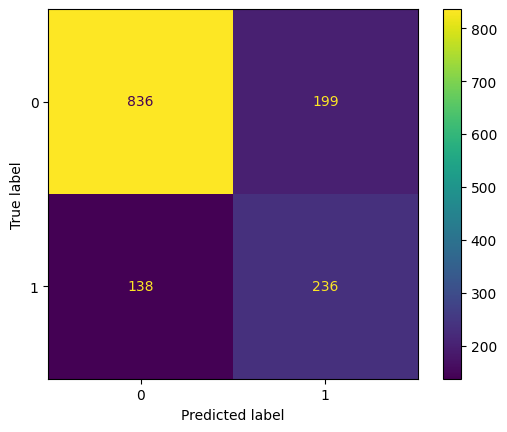

In [13]:
## 8. Logistic Regression Model

log_reg = LogisticRegression(random_state=42,max_iter=1000)

log_reg.fit(x_train_sm_scaled,y_train_sm)

y_pred_lr = log_reg.predict(x_test_scaled)
print(y_pred_lr)
print(accuracy_score(y_test,y_pred_lr))
print(classification_report(y_test,y_pred_lr))
print(confusion_matrix(y_test,y_pred_lr))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_lr))

[0 1 0 ... 0 0 0]
0.7750177430801988
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1035
           1       0.57      0.60      0.58       374

    accuracy                           0.78      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

[[869 166]
 [151 223]]


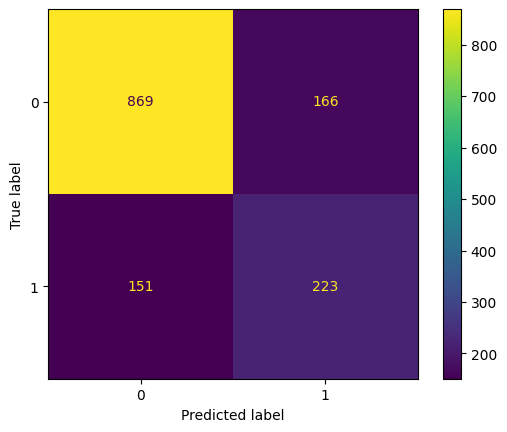

In [15]:
## 9. Random Forest Model

rf = RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(x_train_sm, y_train_sm)
y_pred_rf = rf.predict(x_test)
print(y_pred_rf)
print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_rf))